In [1]:
import torch
import torch.nn as nn

#Try to use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
        self.relu  = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride=stride)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        out = out + self.shortcut(x)   # Residual (skip) connection
        out = self.relu(out)
        return out


class SimpleResNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.relu  = nn.ReLU()

        self.layer1 = ResidualBlock(32, 32)
        self.layer2 = ResidualBlock(32, 64, stride=2)
        self.layer3 = ResidualBlock(64, 64)

        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc   = nn.Linear(64, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = SimpleResNet()
print(model)


Using device: cpu
SimpleResNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (layer1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (shortcut): Identity()
  )
  (layer2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (relu): ReLU()
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (shortcut): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2))
  )
  (layer3): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (shortcut): Identity()
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_features=64, out_features=10, bias=True)
)


In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# -------- DATA (load ONCE) --------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(root='.', train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='.', train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True,
    num_workers=2, pin_memory=True
)

test_loader = DataLoader(
    test_dataset, batch_size=128, shuffle=False,
    num_workers=2, pin_memory=True
)

# -------- MODEL --------
model = SimpleResNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

# -------- METRIC TRACKING (FIX) --------
train_losses = []
test_accuracies = []

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    scheduler.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    test_accuracies.append(acc)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1 | Loss: 1.8109 | Acc: 0.4044
Epoch 2 | Loss: 1.4774 | Acc: 0.5075
Epoch 3 | Loss: 1.2774 | Acc: 0.5487
Epoch 4 | Loss: 1.1248 | Acc: 0.5971
Epoch 5 | Loss: 1.0649 | Acc: 0.6260


In [11]:
train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset_aug = datasets.CIFAR10(
    root='.', train=True, download=False,
    transform=train_transform_aug
)

train_loader_aug = DataLoader(
    train_dataset_aug, batch_size=128, shuffle=True,
    num_workers=2, pin_memory=True
)

# test_loader already defined in previous cell

model = SimpleResNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Metric tracking
train_losses_aug = []
test_accuracies_aug = []

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_aug)
    train_losses_aug.append(avg_loss)

    # Evaluate on test set
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    test_accuracies_aug.append(acc)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Test Acc: {acc:.4f}")


Epoch 1 | Loss: 1.8187 | Test Acc: 0.3750
Epoch 2 | Loss: 1.5028 | Test Acc: 0.4970
Epoch 3 | Loss: 1.3330 | Test Acc: 0.5416
Epoch 4 | Loss: 1.1824 | Test Acc: 0.5954
Epoch 5 | Loss: 1.0641 | Test Acc: 0.6381


In [5]:
model = SimpleResNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(), lr=0.001, weight_decay=1e-4
)

# -------- METRIC TRACKING (FIX) --------
reg_train_losses = []
reg_test_accuracies = []

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    reg_train_losses.append(avg_loss)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    reg_test_accuracies.append(acc)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}")


Epoch 1 | Loss: 1.7899 | Acc: 0.4018
Epoch 2 | Loss: 1.4963 | Acc: 0.4717
Epoch 3 | Loss: 1.3259 | Acc: 0.5270
Epoch 4 | Loss: 1.2020 | Acc: 0.5680
Epoch 5 | Loss: 1.0994 | Acc: 0.6226


In [6]:
#Umar's Part Starts Here#
#Tracking training curves
import matplotlib.pyplot as plt


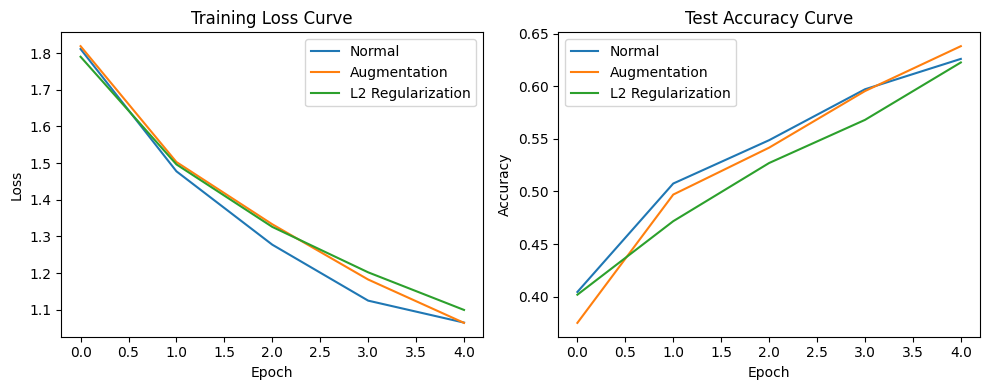

In [12]:
# Combined Training Curves with Markers
plt.figure(figsize=(12,5))

# ---- Training Loss ----
plt.subplot(1,2,1)
plt.plot(train_losses, 'o-', label="Normal", color='blue')
plt.plot(train_losses_aug, 's-', label="Augmentation", color='green')
plt.plot(reg_train_losses, '^-', label="L2 Regularization", color='red')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

# ---- Test Accuracy ----
plt.subplot(1,2,2)
plt.plot(test_accuracies, 'o-', label="Normal", color='blue')
plt.plot(test_accuracies_aug, 's-', label="Augmentation", color='green')
plt.plot(reg_test_accuracies, '^-', label="L2 Regularization", color='red')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [8]:
#Overall accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Final Test Accuracy:", correct / total)


Final Test Accuracy: 0.6226


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


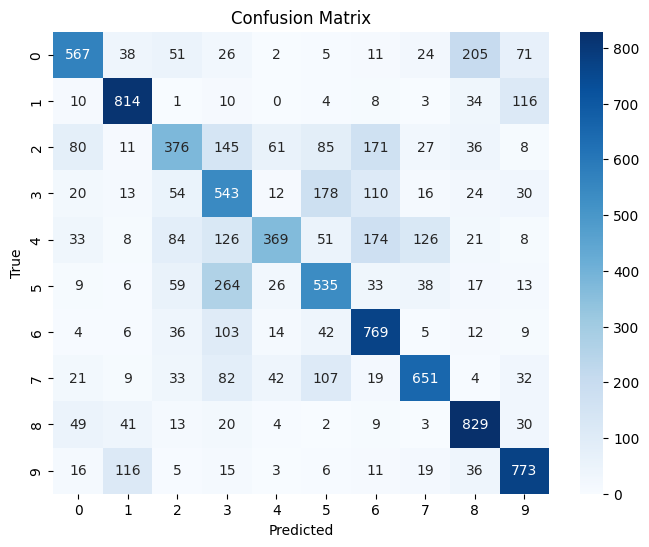

In [9]:
#Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [10]:
#Per class accuracy
classes = train_dataset.classes
class_correct = [0]*10
class_total = [0]*10

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (preds[i] == labels[i]).item()
            class_total[label] += 1

for i in range(10):
    print(f"{classes[i]} Accuracy: {class_correct[i]/class_total[i]:.4f}")
#Umar's part ends here#


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


airplane Accuracy: 0.5670
automobile Accuracy: 0.8140
bird Accuracy: 0.3760
cat Accuracy: 0.5430
deer Accuracy: 0.3690
dog Accuracy: 0.5350
frog Accuracy: 0.7690
horse Accuracy: 0.6510
ship Accuracy: 0.8290
truck Accuracy: 0.7730


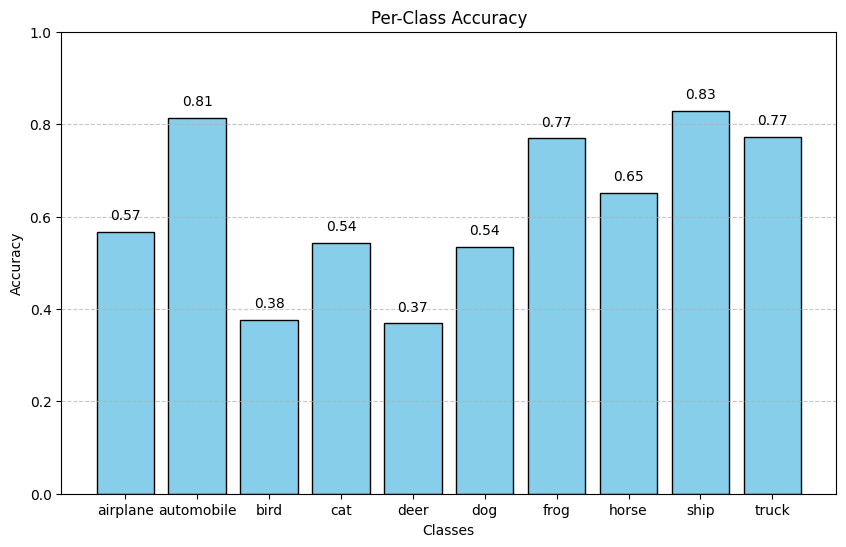

In [13]:
# Compute per-class accuracy
class_accuracy = [class_correct[i] / class_total[i] for i in range(10)]

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(classes, class_accuracy, color='skyblue', edgecolor='black')
plt.ylim(0, 1)
plt.xlabel("Classes")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: show accuracy values on top of bars
for bar, acc in zip(bars, class_accuracy):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{acc:.2f}", ha='center', va='bottom')

plt.show()